In [1]:
# Just following along with:
# https://github.com/tintn/vision-transformer-from-scratch

In [2]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
    colab = True
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'
    colab = False

print('Will store datasets in', dataset_root)

import os

if os.name == 'nt':
    print("Disabling multiprocessing because we're running on windows.")
    cpu_num = 0
elif colab:
    cpu_num = 2
else:
    cpu_num = os.cpu_count() // 2
    print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google.colab'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 12 CPUs


In [3]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as tvt
import torchvision.transforms.v2 as tv2
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu
import torchinfo

from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
class ScaleToUnit(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        x = x / 255.0
        return x

train_tfs = tvt.Compose([
    tv2.ToImage(),
    tv2.RandomCrop(32, 4),
    # tvt.ColorJitter(
    #     brightness=0.2,
    #     contrast=0.2,
    #     saturation=0.2,
    #     hue=0.1
    # ),
    tv2.RandomHorizontalFlip(0.5),
    tv2.RandomVerticalFlip(0.25),
    tv2.ToDtype(torch.float32, scale=True),
    tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    # tv2.Resize((320,320)),
])

val_tfs = tvt.Compose([
    tv2.ToImage(),
    tv2.ToDtype(torch.float32, scale=True),
    tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    # tv2.Resize((320,320)),
])

cifar_train = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=True,
    transform=train_tfs,
)
cifar_eval = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=False,
    transform=val_tfs,
)
cifar_train = tds.wrap_dataset_for_transforms_v2(cifar_train)
cifar_eval = tds.wrap_dataset_for_transforms_v2(cifar_eval)

Files already downloaded and verified
Files already downloaded and verified


In [5]:
batchsize = 256

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([64, 3, 32, 32]) tensor(-0.1565)


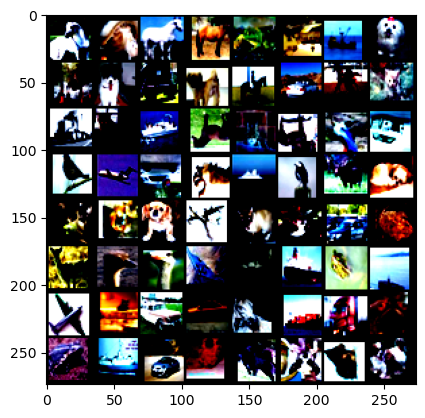

In [6]:
def random_grid(imgs, sz: int):
    grid = tu.make_grid(imgs)
    return grid.permute(1, 2, 0)

num=64
augmented = torch.stack([x[0] for x in random.choices(cifar_train, k=num)])
print(augmented.shape, augmented.mean())
tmps = random_grid(augmented, num)
plt.imshow(tmps.cpu())

In [16]:
# Input B C H W
class Tokenizer(nn.Module):
    def __init__(self, c_in, emb_len, patch_dim):
        super().__init__()
        self.conv0 = nn.Conv2d(c_in, emb_len, patch_dim, stride=patch_dim)
    
    def forward(self, x):
        x = self.conv0(x)
        x = x.flatten(2)
        x = x.permute(0, 2, 1)
        return x

# Input B, (P * P), C
class Embeddings(nn.Module):
    def __init__(self, emb_len, patch_num, dropout=0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_len))
        self.pos_emb = nn.Parameter(
            torch.randn(1, patch_num + 1, emb_len)
        )
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        b, p2, c = x.shape
        
        cls_tok = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tok, x), dim=1)
        x = x + self.pos_emb # I think pos_emb is automatically broadcast in the batch dimension here.
        x = self.dropout(x)
        return x

class Transformer(nn.Module):
    def __init__(self, emb_len, patch_num, layers=8, heads=4, dim_ff=512, dropout=0.1):
        super().__init__()
        # layer_norm = nn.LayerNorm(emb_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_len,
            nhead=heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True # <-- This took me forever to find, default is to place batch in the second dimension
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers,
            # norm=layer_norm
        )
    
    def forward(self, x):
        y = self.transformer(x)
        return y

class ClassHead(nn.Module):
    def __init__(self, emb_len, patch_num, hidden_sz, classes, dropout=0.1):
        super().__init__()
        self.fc0 = nn.Linear(emb_len, hidden_sz)
        self.activation = nn.ReLU()
        self.fc1 = nn.Linear(hidden_sz, classes)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, inp):
        x = inp[:, 0, :]
        # x = inp.flatten(1)
        x = self.fc0(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.fc1(x)

        return x

class VIT(nn.Module):
    def __init__(self, num_classes, patchsz, emb_dim, dim_ff=64):
        super().__init__()
        self.tokenizer = Tokenizer(3, emb_dim, patchsz)
        self.embeddings = Embeddings(emb_dim, patch_num, 0.1) # 400 = (640 / 32)^2
        self.transformer = Transformer(emb_dim, patch_num + 1, layers=4, heads=4, dim_ff=dim_ff)
        self.class_head = ClassHead(emb_dim, patch_num + 1, 256, num_classes)
        
        self.initializer_range = 0.2
        
        # self.apply(self._init_weights)
        
    def forward(self, x):
        x = self.tokenizer(x)
        x = self.embeddings(x)
        x = self.transformer(x)
        x = self.class_head(x)
        return x
    
    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Conv2d)):
            torch.nn.init.normal_(module.weight, mean=0.0, std=self.initializer_range)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)
        elif isinstance(module, Embeddings):
            module.pos_emb.data = nn.init.trunc_normal_(
                module.pos_emb.data.to(torch.float32),
                mean=0.0,
                std=self.initializer_range,
            ).to(module.pos_emb.dtype)

            module.cls_token.data = nn.init.trunc_normal_(
                module.cls_token.data.to(torch.float32),
                mean=0.0,
                std=self.initializer_range,
            ).to(module.cls_token.dtype)

In [17]:
imgsz = 32
patchsz = 4
emb_dim = 128

patch_num = (imgsz // patchsz)**2
vit_test = VIT(10, patchsz, emb_dim)

with torch.no_grad():
    print(torchinfo.summary(vit_test, (batchsize, 3, imgsz, imgsz)))

Layer (type:depth-idx)                             Output Shape              Param #
VIT                                                [256, 10]                 --
├─Tokenizer: 1-1                                   [256, 64, 128]            --
│    └─Conv2d: 2-1                                 [256, 128, 8, 8]          6,272
├─Embeddings: 1-2                                  [256, 65, 128]            8,448
│    └─Dropout: 2-2                                [256, 65, 128]            --
├─Transformer: 1-3                                 [256, 65, 128]            --
│    └─TransformerEncoder: 2-3                     [256, 65, 128]            --
│    │    └─ModuleList: 3-1                        --                        332,544
├─ClassHead: 1-4                                   [256, 10]                 --
│    └─Linear: 2-4                                 [256, 256]                33,024
│    └─ReLU: 2-5                                   [256, 256]                --
│    └─Dropout: 2-6 

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 41.78it/s]


Curren loss is 1.7707151174545288, Current LR is [0.0009999383162408303]
3474/10000 correct, 34.74%


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 40.66it/s]


Curren loss is 1.5047869682312012, Current LR is [0.0009997532801828658]
4482/10000 correct, 44.82%


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 41.33it/s]


...

Curren loss is 0.7176724672317505, Current LR is [2.4671981713419966e-07]
7818/10000 correct, 78.18%


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 41.10it/s]


Curren loss is 0.7079071998596191, Current LR is [6.168375916970607e-08]
7813/10000 correct, 78.13%


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 41.53it/s]

Curren loss is 0.738246738910675, Current LR is [0.0]
7814/10000 correct, 78.14%
CPU times: user 8min 11s, sys: 2min 22s, total: 10min 34s
Wall time: 10min 58s


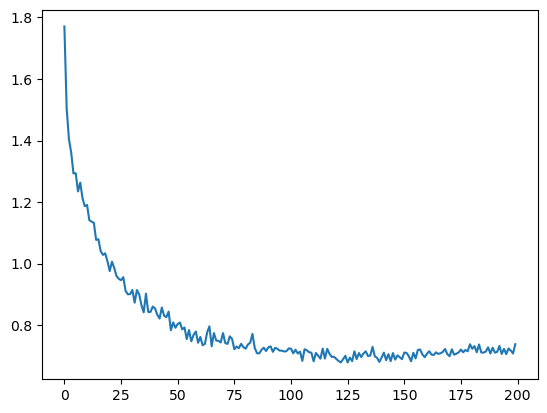

In [18]:
%%time
device='cuda'
model = VIT(10, patchsz, emb_dim, dim_ff=128).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
lossfn = nn.CrossEntropyLoss()
epochs = 200

loss_plot = []
for epoch in range(epochs):
    model.train()
    for i, (images, target) in enumerate(tqdm(train_loader)):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.to(device)

        outs = model(images)
        loss = lossfn(outs, targets)
        loss.backward()
        optimizer.step()

    losses = []
    model.eval()
    correct = 0
    total = len(cifar_eval)
    for i, (images, target) in enumerate(tqdm(val_loader)):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.to(device)
            outs = model(images)
            loss = lossfn(outs, targets)
            losses.append(loss)
            for x in range(outs.shape[0]):
                preds = F.softmax(outs, dim=1)
                cls = preds[x].argmax()
                lbl = targets[x]
                if cls == lbl:
                    correct += 1

    scheduler.step()
    epoch_loss = torch.Tensor(losses).mean().item()
    print("Curren loss is {}, Current LR is {}".format(epoch_loss, scheduler.get_last_lr()))
    print("{}/{} correct, {:.2f}%".format(correct, total, 100*correct/total))
    loss_plot.append(epoch_loss)

plt.plot(loss_plot)

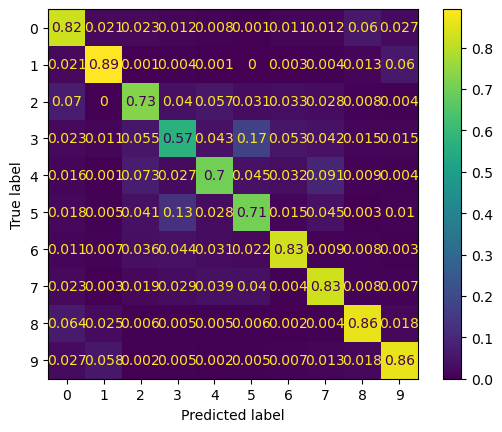

In [19]:
# !pip install scikit-learn 
from sklearn import metrics

evals = cifar_eval
right = 0
total = 0
y_pred=[]
y_true=[]

model.eval()
with torch.no_grad():
    for image, target in evals:
        pred = model(image.unsqueeze(0).float().to(device))
        pred = F.softmax(pred, dim=1).argmax()
        
        y_pred.append(pred.item())
        y_true.append(target)

metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize='true')